In [51]:
!pip install tensorboard

  Using cached werkzeug-3.1.8-py3-none-any.whl.metadata (4.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 11.8 MB/s  0:00:00 11.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 13.1 MB/s  0:00:003.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 13.0 MB/s  0:00:00 13.1 MB/s eta 0:00:01
Using cached werkzeug-3.1.8-py3-none-any.whl (226 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [tensorboard] 6/7 [tensorboard]o]


In [52]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from torch.utils.tensorboard import SummaryWriter


In [53]:
writer = SummaryWriter()

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [70]:
import chess.pgn
import pandas as pd

PGN_FILE = "./game.pgn"      # Path to your PGN file
NUM_GAMES = 30000

games_data = []

with open(PGN_FILE, "r", encoding="utf-8") as pgn:
    for game_number in range(NUM_GAMES):
        game = chess.pgn.read_game(pgn)

        if game is None:
            print("Reached end of PGN file.")
            break

        # Extract moves in SAN notation
        board = game.board()
        moves = [move.uci() for move in game.mainline_moves()]

        games_data.append({
            "game_id": game_number,
            "moves": moves
        })

df = pd.DataFrame(games_data)

print(df.head())
print(f"\nNumber of games extracted: {len(df)}")

   game_id                                              moves
0        0                                                 []
1        1  [e2e4, e7e6, d2d3, d7d5, b1d2, d5e4, d2e4, b7b...
2        2  [d2d4, c7c5, c2c4, c5d4, g1f3, b8c6, e2e3, e7e...
3        3  [e2e4, c7c5, g1f3, d7d6, d2d4, c5d4, f3d4, g8f...
4        4  [c2c4, e7e6, g1f3, a7a6, g2g3, g7g6, f1g2, f8g...

Number of games extracted: 30000


In [71]:
vocabulary = []

In [72]:
for i in df["moves"]:
    for j in i:
        if j not in vocabulary:
            vocabulary.append(j)

In [73]:
len(vocabulary)

1888

In [74]:
from collections import Counter

def build_vocab(df, min_freq=2):
    """
    Scans every game's move list, counts frequency of each unique move-token,
    and builds a fixed vocab: only moves appearing >= min_freq times get
    their own id. Everything else falls back to <UNK> at encode time.
    """
    counter = Counter()

    for moves in df['moves']:
        counter.update(moves)

    # special tokens always get reserved, fixed ids first
    token_to_id = {
        '<PAD>': 0,
        '<UNK>': 1,
    }

    # sort by frequency descending, purely for readability/debuggability —
    # doesn't affect correctness, but makes it easy to eyeball which moves
    # are common vs rare later
    for token, freq in counter.most_common():
        if freq >= min_freq:
            token_to_id[token] = len(token_to_id)

    return token_to_id, counter


token_to_id, move_counts = build_vocab(df, min_freq=2)

print("vocab size:", len(token_to_id))
print("total unique moves seen:", len(move_counts))
print("moves dropped to <UNK> (below min_freq):", len(move_counts) - (len(token_to_id) - 2))

vocab size: 1871
total unique moves seen: 1888
moves dropped to <UNK> (below min_freq): 19


In [75]:
id_to_token = {v: k for k, v in token_to_id.items()}


In [76]:
token_to_id['<START>'] = len(token_to_id)
id_to_token[token_to_id['<START>']] = '<START>'

In [77]:
token_to_id["<START>"]

1871

In [93]:
import json

with open('token_to_id', 'w') as file:
    json.dump(token_to_id, file)

with open('id_to_token', 'w') as file:
    json.dump(id_to_token, file)
    

In [94]:
import sys
print(sys.executable)


/home/lyncan/anaconda3/envs/lyncan/bin/python


In [78]:
class Decoder:
    def __init__(self):
        pass

In [79]:
class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-5):
        super().__init__()  # registers this module

        # gamma (scale) and beta (shift) — the LEARNABLE parameters of LayerNorm.
        # nn.Parameter tells PyTorch "this tensor needs a gradient and should
        # be included in model.parameters()" — this is the manual version of
        # what nn.Linear does automatically for you under the hood.
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        
        self.eps = eps  # small constant for numerical stability, NOT a parameter
                          # (no gradient needed, it's just a fixed hyperparameter)

    def forward(self, x):
        # x: (B, T, d_model)
        
        # normalize across the LAST dimension (d_model) — i.e. per token,
        # across its own feature vector. NOT across batch, NOT across sequence.
        mean = x.mean(dim=-1, keepdim=True)   # (B, T, 1)
        var = x.var(dim=-1, keepdim=True, unbiased=False)  # (B, T, 1)

        x_norm = (x - mean) / torch.sqrt(var + self.eps)

        # scale and shift — learned per-feature, broadcasts across (B, T, d_model)
        out = self.gamma * x_norm + self.beta
        return out

In [80]:
class MaskedMultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()  # mandatory — registers this module's params/submodules
        
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        # Q, K, V projections. nn.Linear creates weight + bias as nn.Parameter
        # automatically — these get registered the moment you assign
        # self.q_proj = ..., because nn.Module.__setattr__ intercepts it.
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)

        # output projection after concatenating heads back together
        self.out_proj = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # x: (B, T, d_model)
        B, T, _ = x.shape

        # linear projections — autograd records these matmuls automatically
        Q = self.q_proj(x)   # (B, T, d_model)
        K = self.k_proj(x)
        V = self.v_proj(x)

        # split into heads: (B, T, d_model) -> (B, n_heads, T, d_head)
        Q = Q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = K.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        V = V.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        # scaled dot-product attention scores: (B, n_heads, T, T)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_head)

        # causal mask: prevents attending to future positions
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # weighted sum of values: (B, n_heads, T, d_head)
        out = attn_weights @ V

        # merge heads back: (B, n_heads, T, d_head) -> (B, T, d_model)
        out = out.transpose(1, 2).contiguous().view(B, T, self.d_model)

        # final output projection
        out = self.out_proj(out)
        return out

In [81]:
def build_causal_mask(T, device):
    # lower-triangular matrix of 1s: position i can attend to positions <= i
    mask = torch.tril(torch.ones(T, T, device=device)).unsqueeze(0).unsqueeze(0)
    # shape: (1, 1, T, T) — broadcastable across batch and heads
    return mask

In [82]:

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        # two linear layers with an expansion in between:
        # d_model -> d_ff -> d_model
        # d_ff is typically 4x d_model (that's the convention from the
        # original transformer paper — worth knowing it's a convention,
        # not a mathematical requirement)
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, T, d_model)
        x = self.linear1(x)      # (B, T, d_ff)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.linear2(x)      # (B, T, d_model)
        return x

In [83]:
class Linear(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features

        # weight matrix: shape (out_features, in_features)
        # note the shape convention — it's (out, in), not (in, out).
        # this is because of how the forward pass does x @ W.T
        self.weight = nn.Parameter(torch.empty(out_features, in_features))

        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter('bias', None)
            # register_parameter with None tells PyTorch "there's no bias here,
            # but don't error if something looks for self.bias" — different
            # from just not setting self.bias at all

        self.reset_parameters()

    def reset_parameters(self):
        # weight initialization — NOT arbitrary. This is Kaiming/He-style init,
        # scaled by fan_in, meant to keep activation variance stable across
        # layers at the start of training. Worth thinking about WHY bad init
        # causes vanishing/exploding activations — same underlying concern
        # as the vanishing/exploding gradient asymmetry you already covered
        # with residual connections.
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        
        if self.bias is not None:
            fan_in = self.in_features
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        # x: (..., in_features)  — any number of leading dims (B, T, in_features) etc.
        out = x @ self.weight.T
        if self.bias is not None:
            out = out + self.bias
        return out
        # out: (..., out_features)

In [84]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MaskedMultiHeadAttention(d_model, n_heads, dropout)
        self.norm1 = LayerNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm2 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Pre-LN: normalize BEFORE the sublayer, residual adds the RAW sublayer output
        # (this is the ordering you reasoned through earlier for gradient flow stability
        # at depth — Post-LN is more prone to training instability in deep stacks)
        attn_out = self.attn(self.norm1(x), mask)
        x = x + self.dropout(attn_out)

        ffn_out = self.ffn(self.norm2(x))
        x = x + self.dropout(ffn_out)

        return x

In [85]:
class ChessGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, max_seq_len, dropout=0.1):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model)

        # learned positional embeddings — a lookup table, same mechanism as
        # token_embedding, just indexed by position instead of token id
        self.positional_embedding = nn.Embedding(max_seq_len, d_model)

        self.dropout = nn.Dropout(dropout)

        # ModuleList — NOT a plain list. this is what makes .parameters()
        # find every block's weights, as we covered.
        self.blocks = nn.ModuleList([
            DecoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

        self.final_norm = LayerNorm(d_model)

        # separate output head (not tied to token_embedding here — 
        # tying is a valid alternative, worth trying later as an experiment)
        self.output_head = Linear(d_model, vocab_size)

        # causal mask precomputed once for max_seq_len, sliced per forward call
        # register_buffer: NOT a Parameter (no gradient, not updated by optimizer),
        # but still moves with the model when you call model.to(device)
        causal_mask = torch.tril(torch.ones(max_seq_len, max_seq_len)).unsqueeze(0).unsqueeze(0)
        self.register_buffer('causal_mask', causal_mask)

    def forward(self, token_ids):
        # token_ids: (B, T)
        B, T = token_ids.shape

        tok_emb = self.token_embedding(token_ids)          # (B, T, d_model)

        positions = torch.arange(T, device=token_ids.device)  # (T,)
        pos_emb = self.positional_embedding(positions)      # (T, d_model)

        x = self.dropout(tok_emb + pos_emb)                  # (B, T, d_model), broadcasts pos_emb across batch

        mask = self.causal_mask[:, :, :T, :T]                # slice to current sequence length

        for block in self.blocks:
            x = block(x, mask)

        x = self.final_norm(x)
        logits = self.output_head(x)                         # (B, T, vocab_size)

        return logits

In [86]:
model = ChessGPT(vocab_size=len(token_to_id), d_model=512, n_heads=8, d_ff=2048, n_layers=10, max_seq_len=250).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(total_params)

33571664


In [87]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=0)

In [88]:
from torch.utils.data import Dataset, DataLoader

from functools import partial

class ChessDataset(Dataset):
    def __init__(self, df, max_seq_len, pad_id):
        self.games = df['token_ids'].tolist()
        self.max_seq_len = max_seq_len
        self.pad_id = pad_id

    def __len__(self):
        return len(self.games)

    def __getitem__(self, idx):
        ids = self.games[idx][:self.max_seq_len + 1]  # +1 for shift-by-one
        return ids


def collate_fn(batch, pad_id):
    max_len = max(len(seq) for seq in batch)
    padded = [seq + [pad_id] * (max_len - len(seq)) for seq in batch]
    padded = torch.tensor(padded, dtype=torch.long)
    input_ids = padded[:, :-1]
    target_ids = padded[:, 1:]
    return input_ids, target_ids


In [89]:
def encode_games(df, token_to_id):
    """
    Converts each game's move-string list into a list of integer ids,
    using <UNK> for any move not present in the vocab (i.e. below the
    min_freq cutoff at vocab-build time).
    """
    unk_id = token_to_id['<UNK>']

    def encode(moves):
        return [token_to_id.get(move, unk_id) for move in moves]

    df['token_ids'] = df['moves'].apply(encode)
    return df


df = encode_games(df, token_to_id)

In [90]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.05, random_state=42)

pad_id = token_to_id['<PAD>']
max_seq_len = 250  # <- replace with YOUR actual percentile-derived number

train_dataset = ChessDataset(train_df, max_seq_len, pad_id)
val_dataset = ChessDataset(val_df, max_seq_len, pad_id)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                           collate_fn=partial(collate_fn, pad_id=pad_id))
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,
                         collate_fn=partial(collate_fn, pad_id=pad_id))

In [91]:
n_epochs = 100

for epoch in range(n_epochs):
    model.train()
    total_train_loss = 0.0

    for input_ids, target_ids in train_loader:
        input_ids, target_ids = input_ids.to(device), target_ids.to(device)

        optimizer.zero_grad()
        logits = model(input_ids)
        loss = criterion(logits.view(-1, logits.size(-1)), target_ids.view(-1))
        loss.backward()
        optimizer.step()


        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    if epoch % 5 == 0:
        torch.save(model.state_dict(), f'checkpoint_epoch_{epoch}.pt')


    # ---- validation ----
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for input_ids, target_ids in val_loader:
            input_ids, target_ids = input_ids.to(device), target_ids.to(device)
            logits = model(input_ids)
            loss = criterion(logits.view(-1, logits.size(-1)), target_ids.view(-1))
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{n_epochs} — train loss: {avg_train_loss:.4f} — val loss: {avg_val_loss:.4f}")

Epoch 1/100 — train loss: 4.9906 — val loss: 4.2429
Epoch 2/100 — train loss: 3.9095 — val loss: 3.5869
Epoch 3/100 — train loss: 3.4016 — val loss: 3.3285
Epoch 4/100 — train loss: 3.1037 — val loss: 3.2074
Epoch 5/100 — train loss: 2.8781 — val loss: 3.1513
Epoch 6/100 — train loss: 2.6857 — val loss: 3.1382
Epoch 7/100 — train loss: 2.5129 — val loss: 3.1493
Epoch 8/100 — train loss: 2.3501 — val loss: 3.1925
Epoch 9/100 — train loss: 2.2010 — val loss: 3.2441
Epoch 10/100 — train loss: 2.0638 — val loss: 3.3035
Epoch 11/100 — train loss: 1.9359 — val loss: 3.3801
Epoch 12/100 — train loss: 1.8206 — val loss: 3.4606
Epoch 13/100 — train loss: 1.7156 — val loss: 3.5353
Epoch 14/100 — train loss: 1.6201 — val loss: 3.6244
Epoch 15/100 — train loss: 1.5318 — val loss: 3.7040
Epoch 16/100 — train loss: 1.4550 — val loss: 3.7914
Epoch 17/100 — train loss: 1.3853 — val loss: 3.8729
Epoch 18/100 — train loss: 1.3241 — val loss: 3.9397
Epoch 19/100 — train loss: 1.2671 — val loss: 4.0154
Ep

KeyboardInterrupt: 

In [28]:
def generate(model, token_to_id, id_to_token, prompt_ids, max_new_tokens, device, temperature=1.0):
    model.eval()
    ids = prompt_ids.copy()

    for _ in range(max_new_tokens):
        input_tensor = torch.tensor([ids], dtype=torch.long).to(device)  # (1, T)

        with torch.no_grad():
            logits = model(input_tensor)  # (1, T, vocab_size)

        # only care about the prediction for the NEXT token — last position
        next_token_logits = logits[0, -1, :] / temperature  # (vocab_size,)

        probs = torch.softmax(next_token_logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1).item()

        ids.append(next_id)

    return ids

In [32]:
model.eval()
ids = [token_to_id['e2e4']]
print("ids:", ids)

input_tensor = torch.tensor([ids], dtype=torch.long).to(device)

ids: [4]


In [33]:
print("input_tensor:", input_tensor, input_tensor.device)

with torch.no_grad():
    logits = model(input_tensor)

print("logits shape:", logits.shape)

input_tensor: tensor([[4]], device='cuda:0') cuda:0
logits shape: torch.Size([1, 1, 1847])


In [34]:
generate(model, token_to_id, id_to_token, [token_to_id['e2e4']], 1, device, temperature=0.2)

[4, 16]

In [37]:
import chess
import chess.svg
from IPython.display import display, SVG, clear_output
import torch

In [38]:
def get_model_move(model, board, token_to_id, id_to_token, device, temperature=0.7):
    """
    Generates ONE move from the model, constrained to legal moves only.
    Uses the game history so far (as token ids) as context.
    """
    legal_moves_uci = [move.uci() for move in board.legal_moves]
    legal_ids = [token_to_id[m] for m in legal_moves_uci if m in token_to_id]

    if not legal_ids:
        return None  # no legal moves the model has tokens for

    # current game history, as ids — this needs to track EVERY move played
    # so far in the game, both yours and the model's
    input_tensor = torch.tensor([current_game_ids], dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)

    next_token_logits = logits[0, -1, :] / temperature

    # mask out everything except legal moves, exactly like we discussed
    mask = torch.full_like(next_token_logits, float('-inf'))
    mask[legal_ids] = next_token_logits[legal_ids]

    probs = torch.softmax(mask, dim=-1)
    next_id = torch.multinomial(probs, num_samples=1).item()

    return next_id

In [39]:
def play_game(model, token_to_id, id_to_token, device, human_color=chess.WHITE, temperature=0.7):
    board = chess.Board()
    global current_game_ids
    current_game_ids = []  # tracks the FULL move history as token ids, both players

    while not board.is_game_over():
        clear_output(wait=True)
        display(SVG(chess.svg.board(board, size=400)))
        print(f"Move {board.fullmove_number} — {'White' if board.turn else 'Black'} to move")

        if board.turn == human_color:
            move_uci = input("Your move (UCI, e.g. e2e4): ").strip()
            try:
                move = chess.Move.from_uci(move_uci)
                if move not in board.legal_moves:
                    print("Illegal move, try again.")
                    continue
            except ValueError:
                print("Invalid UCI format, try again.")
                continue

            board.push(move)
            if move_uci in token_to_id:
                current_game_ids.append(token_to_id[move_uci])
            else:
                current_game_ids.append(token_to_id['<UNK>'])

        else:
            next_id = get_model_move(model, board, token_to_id, id_to_token, device, temperature)
            if next_id is None:
                print("Model has no legal moves it recognizes — resigning.")
                break

            move_uci = id_to_token[next_id]
            move = chess.Move.from_uci(move_uci)
            print(f"Model plays: {move_uci}")
            board.push(move)
            current_game_ids.append(next_id)

    clear_output(wait=True)
    display(SVG(chess.svg.board(board, size=400)))
    print("Game over:", board.result())

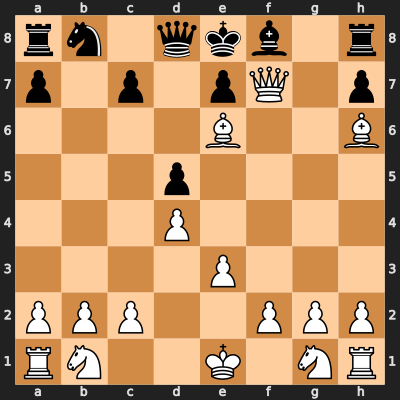

Game over: 1-0


In [45]:
play_game(model, token_to_id, id_to_token, device, human_color=chess.WHITE, temperature=0.7)


In [48]:
torch.save(model.state_dict(), 'chess_gpt.pt')